# Exact enumeration for generative-AI title planning

This notebook uses mixle's enumerable distributions as a symbolic planning layer for scientific-title generation. The data are real NeurIPS submission records from the local notebook dataset, and the experiment asks a concrete question:

Can exact enumeration give us high-probability, constraint-satisfying title plans for a topic-conditioned generator, and how does that compare with sampling?

The generator here is deliberately split into two pieces:

1. a probabilistic planner over compact title templates, implemented with mixle distributions; and
2. a small realizer that fills template slots from the held-out abstract and the training corpus.

That split mirrors a common data-to-text idea: plan the symbolic content first, then realize it in surface language. It also makes the enumeration capability easy to measure: likelihood, coverage, exact top-k plans, cumulative mass scanned, and sampling recall.


## Decoding strategies: how a generator turns probabilities into text

Every text generator -- from this enumerable planner to a billion-parameter language model -- is an
autoregressive distribution $p(x_1,\dots,x_T) = \prod_t p(x_t \mid x_{<t})$: it assigns a probability to every
possible sequence. Generation is then a search problem: pick a sequence given those probabilities. The choice
of how is the decoding strategy, and it matters as much as the model.

- Greedy decoding takes the most probable next token at every step. Fast, deterministic, but myopic -- a
  locally-best token can lead into a globally poor sequence, and it cannot recover.
- Beam search keeps the $k$ highest-probability partial sequences at each step, approximating the most
  probable whole sequence. Better than greedy for tasks with one right answer (translation, the constrained
  title here), but it is still an approximation and tends to produce generic, repetitive text on open-ended
  tasks (the "beam search curse").
- Pure sampling draws each token from $p(x_t \mid x_{<t})$. Diverse and surprising, but prone to incoherent
  tails because the long, low-probability tail of the vocabulary collectively carries real mass.
- Temperature scaling sharpens ($\tau<1$, toward greedy) or flattens ($\tau>1$, more random) the distribution
  before sampling, trading coherence against diversity.
- Top-k and nucleus (top-p) sampling truncate the tail -- sample only from the $k$ most likely tokens, or from
  the smallest set whose cumulative probability exceeds $p$ -- the standard fix that keeps sampling diverse but
  coherent.

These strategies all approximate or sample from the model's distribution. The distinctive move in this
notebook is exact enumeration: for an enumerable distribution we can list candidate sequences in exact
non-increasing probability order, giving provably-top-$k$ decoding and exact constrained decoding -- no
heuristic search, no sampling variance. The trade-off is that enumeration is only possible for distributions
with finite, tractable support (the planner over compact templates here), which is why real systems pair a
symbolic, enumerable planner with a neural realizer.

## Search versus sampling, and where exact enumeration fits

The two goals of decoding pull in opposite directions. Search (greedy, beam, enumeration) seeks the
highest-probability output -- right for tasks with a correct answer and for satisfying hard constraints.
Sampling (with temperature, top-k, nucleus) seeks diversity and human-like variety -- right for open-ended
generation, where always emitting the single most probable continuation is bland and repetitive. The famous
observation that the most likely sequence is often not the best output (maximisation produces degenerate,
looping text in large models) is why open-ended generation samples rather than maximises.

Constrained decoding -- "the title must mention the topic and contain a relation word" -- is where the two meet,
and where exact enumeration shines. A sampler can only satisfy constraints by rejection (generate, check,
discard), never knowing whether it has found the best feasible candidates; beam search must bolt constraints
onto its heuristic. Enumeration walks candidates in exact probability order and returns the provably top-$k$
feasible ones, with an exact account of how much probability mass was scanned to find them. The experiments
below make this concrete: enumeration's constrained top-$k$ versus rejection sampling for the same editorial
rules, on real NeurIPS title statistics.

## Sources and related work

* The records come from the NeurIPS proceedings corpus included in this repository; the public proceedings are at papers.nips.cc (https://papers.nips.cc/).
* Title generation for papers is usually framed as a special case of abstractive summarization; see, for example, Can pre-trained language models generate titles for research papers? (https://arxiv.org/html/2409.14602v1).
* The planner/realizer decomposition follows the spirit of symbolic planning before neural realization in data-to-text generation, as in Moryossef, Goldberg, and Dagan, 2019 (https://aclanthology.org/N19-1236/).
* Beam search and stochastic decoders are common alternatives for neural text generation; for background, see Freitag and Al-Onaizan, 2017 (https://aclanthology.org/W17-3207/) and Holtzman et al., 2019 (https://arxiv.org/abs/1904.09751).

This is not a state-of-the-art title generator. It is a publishable-style pilot experiment for an exact symbolic decoding component: the planner is transparent, the split is reproducible, and the metrics reveal where exact enumeration helps and where richer modeling would be needed.


In [1]:
PYSP_DATA_LOC = '../../data'

import json
import math
import os
import re
import time
import warnings
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mixle.stats import *
from mixle.stats import EnumerationError
from mixle.enumeration import supports_enumeration
from mixle.inference import estimate

%matplotlib inline

rng = np.random.RandomState(4)

## The enumeration contract

mixle exposes enumeration through `distribution.enumerator()`. For an enumerable distribution, the enumerator yields `(value, log_probability)` pairs in non-increasing probability order. That lets us do exact top-k decoding, exact cumulative mass accounting over the values we have scanned, and deterministic constrained decoding.

Non-discrete distributions do not have finite enumerable support, so they raise an `EnumerationError`.


In [2]:
def compact_sequence(seq):
    return ''.join(seq)


toy_hmm = HiddenMarkovModelDistribution(
    topics=[
        CategoricalDistribution({'a': 0.70, 'b': 0.25, 'c': 0.05}),
        CategoricalDistribution({'x': 0.60, 'y': 0.30, 'z': 0.10}),
    ],
    w=[0.7, 0.3],
    transitions=[[0.85, 0.15], [0.25, 0.75]],
    len_dist=IntegerCategoricalDistribution(2, [0.1, 0.4, 0.3, 0.2]),
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    toy_items = toy_hmm.enumerator().top_k(12)
    log_density_matches = [
        np.allclose(lp, toy_hmm.log_density(x))
        for x, lp in toy_items
    ]

toy_df = pd.DataFrame({
    'rank': range(1, len(toy_items) + 1),
    'sequence': [compact_sequence(x) for x, _ in toy_items],
    'probability': [math.exp(lp) for _, lp in toy_items],
    'log density matches': log_density_matches,
})

print('supports_enumeration(toy_hmm) =', supports_enumeration(toy_hmm))
print('non-increasing probabilities =', all(
    toy_items[i][1] >= toy_items[i + 1][1] - 1.0e-12
    for i in range(len(toy_items) - 1)
))
toy_df

supports_enumeration(toy_hmm) = True
non-increasing probabilities = True


,rank,sequence,probability,log density matches
0,1,aaa,0.069389,True
1,2,aaaa,0.030965,True
2,3,aa,0.029155,True
3,4,aab,0.024782,True
4,5,baa,0.024782,True
5,6,aba,0.024782,True
6,7,xxx,0.014580,True
7,8,aaaaa,0.012283,True
8,9,aaab,0.011059,True
9,10,aaba,0.011059,True


In [3]:
try:
    GaussianDistribution(0.0, 1.0).enumerator()
except EnumerationError as err:
    print(err)

GaussianDistribution does not support enumeration


## Data: NeurIPS submissions as title-planning records

The local dataset stores tokenized titles and abstracts. We keep papers with moderate-length titles and non-empty abstracts, infer a weak topic label from title and abstract keywords, and split records with a fixed random seed.

The topic labels are intentionally weak supervision. They are not meant to replace a modern classifier; they give us reproducible control codes for testing conditional enumeration.


In [4]:
WORD_RE = re.compile(r'[A-Za-z][A-Za-z0-9-]*|:')


def normalize_token(token):
    token = str(token).strip()
    if token == ':':
        return ':'
    if not WORD_RE.fullmatch(token):
        return None
    token = re.sub(r'^[^a-z0-9]+|[^a-z0-9]+$', '', token.lower())
    return token or None


def normalize_tokens(tokens):
    return [u for u in (normalize_token(t) for t in (tokens or [])) if u]


TOPIC_WORDS = {
    'vision': {'image', 'images', 'visual', 'vision', 'object', 'objects',
               'convolutional', 'cnn', 'video', 'segmentation'},
    'language': {'language', 'text', 'word', 'words', 'speech', 'translation',
                 'document', 'documents', 'topic', 'bert', 'sentence'},
    'reinforcement': {'reinforcement', 'policy', 'policies', 'agent', 'agents',
                      'bandit', 'bandits', 'reward', 'control', 'mdp', 'exploration'},
    'optimization': {'optimization', 'gradient', 'convex', 'descent', 'stochastic',
                     'online', 'regret', 'variational'},
    'graphs': {'graph', 'graphs', 'network', 'networks', 'node', 'nodes', 'structured'},
    'bayesian': {'bayesian', 'posterior', 'gaussian', 'probabilistic',
                 'inference', 'markov', 'monte', 'carlo'},
}

TOPIC_PRIORITY = ['reinforcement', 'bayesian', 'language', 'vision', 'optimization', 'graphs']


def infer_topic(title, abstract):
    scores = {
        name: 3 * sum(t in vocab for t in title) + sum(t in vocab for t in abstract[:150])
        for name, vocab in TOPIC_WORDS.items()
    }
    best_score = max(scores.values())
    if best_score <= 0:
        return 'general'
    tied = {name for name, score in scores.items() if score == best_score}
    for name in TOPIC_PRIORITY:
        if name in tied:
            return name
    return sorted(tied)[0]


with open(os.path.join(PYSP_DATA_LOC, 'nips', 'all_submissions.json'), 'rt') as fin:
    submissions = json.load(fin)

raw_records = []
for paper_id, row in enumerate(submissions):
    title = normalize_tokens(row.get('title'))
    abstract = normalize_tokens(row.get('abstract'))
    if 3 <= len(title) <= 15 and len(abstract) >= 30:
        raw_records.append({
            'paper_id': paper_id,
            'year': row['year'],
            'title': title,
            'abstract': abstract,
            'topic': infer_topic(title, abstract),
            'title_text': ' '.join(title).replace(' :', ':'),
        })

rng.shuffle(raw_records)
train_raw = raw_records[:4500]
test_raw = raw_records[4500:6000]

print('# raw submissions = %d' % len(submissions))
print('# usable records = %d' % len(raw_records))
print('# raw train/test = %d/%d' % (len(train_raw), len(test_raw)))

pd.DataFrame({
    'split': ['train', 'test'],
    'records': [len(train_raw), len(test_raw)],
})

# raw submissions = 9674
# usable records = 6253
# raw train/test = 4500/1500


,split,records
0,train,4500
1,test,1500


## Title plans: keep the scientific vocabulary, slot the long tail

A title plan is a compact token sequence. Frequent scientific title words such as `learning`, `inference`, `graph`, `bayesian`, and `optimization` stay explicit. Rare or highly specific terms become typed slots such as `<TERM>` and `<COMPOUND>`.

The explicit vocabulary is learned only from training titles, so held-out titles cannot leak rare words into the planner.


In [5]:
FUNCTION_WORDS = {'of', 'for', 'with', 'and', 'in', 'on', 'to', 'from',
                  'via', 'using', 'a', 'the', 'an', 'as', 'by', ':'}

STATIC_KEEP = (
    FUNCTION_WORDS
    | set().union(*TOPIC_WORDS.values())
    | {
        'learning', 'neural', 'network', 'networks', 'deep', 'bayesian',
        'models', 'model', 'inference', 'optimization', 'graph', 'graphs',
        'reinforcement', 'data', 'algorithm', 'algorithms', 'kernel', 'sparse',
        'online', 'stochastic', 'efficient', 'robust', 'adaptive', 'supervised',
        'unsupervised', 'semi-supervised', 'representation', 'representations',
        'classification', 'prediction', 'estimation', 'analysis',
    }
)

training_title_counts = Counter(
    token for row in train_raw for token in row['title']
    if token not in FUNCTION_WORDS
)
frequent_training_words = {
    word for word, count in training_title_counts.most_common(180)
    if count >= 6
}
PLAN_VOCAB = STATIC_KEEP | frequent_training_words

SLOT_GROUPS = {
    '<METHOD>': {'algorithm', 'algorithms', 'method', 'methods', 'approach',
                 'framework', 'estimator', 'sampler', 'solver'},
    '<MODEL>': {'model', 'models', 'network', 'networks', 'kernel', 'kernels',
                'process', 'processes', 'tree', 'trees', 'graph', 'graphs'},
    '<TASK>': {'learning', 'inference', 'optimization', 'classification',
               'prediction', 'regression', 'clustering', 'detection',
               'estimation', 'sampling', 'planning', 'control'},
    '<DOMAIN>': {'image', 'images', 'visual', 'vision', 'speech', 'language',
                 'text', 'word', 'words', 'document', 'documents',
                 'reinforcement', 'policy', 'robot', 'game', 'games', 'video'},
    '<THEORY>': {'bound', 'bounds', 'theory', 'analysis', 'convex',
                 'regularization', 'generalization', 'complexity', 'convergence'},
}


def slot_token(token):
    if token in PLAN_VOCAB:
        return token
    for slot_name, vocab in SLOT_GROUPS.items():
        if token in vocab:
            return slot_name
    if '-' in token:
        return '<COMPOUND>'
    return '<TERM>'


def make_plan(title):
    plan = []
    for token in title:
        unit = slot_token(token)
        if unit.startswith('<') and plan and plan[-1] == unit:
            continue
        plan.append(unit)
    return tuple(plan)


def attach_plans(records):
    planned = []
    for row in records:
        plan = make_plan(row['title'])
        if 3 <= len(plan) <= 12:
            planned.append({**row, 'plan': plan})
    return planned


train = attach_plans(train_raw)
test = attach_plans(test_raw)

topic_counts = Counter(row['topic'] for row in train)
print('# planned train/test = %d/%d' % (len(train), len(test)))
print('# explicit planner vocabulary = %d' % len(PLAN_VOCAB))

pd.DataFrame({
    'topic': list(topic_counts.keys()),
    'train records': list(topic_counts.values()),
}).sort_values('train records', ascending=False)

# planned train/test = 4297/1431
# explicit planner vocabulary = 218


,topic,train records
0,optimization,937
6,bayesian,788
1,graphs,739
4,general,650
2,vision,524
3,reinforcement,463
5,language,196


In [6]:
def show_plan(plan):
    return ' '.join(plan).replace(' :', ':')


examples = []
for row in train[:12]:
    examples.append({
        'topic': row['topic'],
        'title': row['title_text'],
        'plan': show_plan(row['plan']),
    })

pd.DataFrame(examples)

,topic,title,plan
0,optimization,robust hypothesis testing using wasserstein un...,robust <TERM> testing using <TERM>
1,optimization,parallel predictive entropy search for batch g...,parallel <TERM> search for <TERM> global optim...
2,optimization,multi-stage convex relaxation for learning wit...,<COMPOUND> convex <TERM> for learning with spa...
3,optimization,dingo: distributed newton-type method for grad...,<TERM>: distributed <COMPOUND> method for <COM...
4,graphs,structure regularization for structured predic...,structure regularization for structured predic...
5,graphs,matrix completion from fewer entries: spectral...,matrix completion from <TERM>: spectral <TERM>...
6,graphs,fast sample-efficient algorithms for structure...,fast <COMPOUND> algorithms for structured <TERM>
7,vision,image synthesis with a single robust classifier,image <TERM> with a <TERM> robust <TERM>
8,vision,tree-structured reinforcement learning for seq...,<COMPOUND> reinforcement learning for sequenti...
9,graphs,entropic graph regularization in non-parametri...,<TERM> graph regularization in <COMPOUND> semi...


## Two planner families

We fit two kinds of enumerable planners.

Factorized sequence planners model a plan as an iid sequence with an empirical length distribution. They generalize to unseen templates but can produce awkward token repetitions unless we constrain them.

Empirical template planners model complete observed plans as categorical outcomes. They have lower held-out coverage, but their enumerated plans are real scientific-title patterns seen in the training data.

This is a realistic modeling tradeoff: coverage versus fidelity.


In [7]:
fit_start = time.time()

plans_by_topic = defaultdict(list)
for row in train:
    plans_by_topic[row['topic']].append(row['plan'])

sequence_global = estimate(
    [list(row['plan']) for row in train],
    SequenceEstimator(CategoricalEstimator(), len_estimator=CategoricalEstimator()),
)

sequence_by_topic = {
    topic: estimate(
        [list(plan) for plan in plans],
        SequenceEstimator(CategoricalEstimator(), len_estimator=CategoricalEstimator()),
    )
    for topic, plans in plans_by_topic.items()
    if len(plans) >= 50
}

template_global = estimate(
    [row['plan'] for row in train],
    CategoricalEstimator(),
)

template_by_topic = {
    topic: estimate(plans, CategoricalEstimator())
    for topic, plans in plans_by_topic.items()
    if len(plans) >= 50
}

topic_prior = {
    topic: len(plans_by_topic[topic]) / sum(len(plans_by_topic[t]) for t in template_by_topic)
    for topic in template_by_topic
}
topic_template_model = ConditionalDistribution(
    template_by_topic,
    given_dist=CategoricalDistribution(topic_prior),
)

print('fit time = %0.3f seconds' % (time.time() - fit_start))
print('sequence_global enumerable =', supports_enumeration(sequence_global))
print('topic_template_model enumerable =', supports_enumeration(topic_template_model))

fit time = 0.252 seconds
sequence_global enumerable = True
topic_template_model enumerable = True


## Held-out likelihood experiment

The first experiment evaluates held-out plan likelihood. For models with finite empirical support, `coverage` is the fraction of test plans that receive finite probability. `bits/plan` is reported only over covered records, so it must be read together with coverage.

Hypothesis: topic conditioning should improve likelihood for the sequence model because title-plan statistics differ by area. The empirical template model should produce high-fidelity enumerable candidates but cover fewer unseen test titles.


In [8]:
def finite_metrics(name, log_density_fn):
    lps = []
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        for row in test:
            try:
                lps.append(log_density_fn(row))
            except Exception:
                lps.append(float('-inf'))
    lps = np.asarray(lps, dtype=float)
    finite = np.isfinite(lps)
    if finite.sum() == 0:
        bits_per_plan = np.nan
    else:
        bits_per_plan = -np.mean(lps[finite]) / math.log(2.0)
    return {
        'model': name,
        'coverage': float(finite.mean()),
        'bits/plan on covered records': bits_per_plan,
        '# covered': int(finite.sum()),
    }


metrics_df = pd.DataFrame([
    finite_metrics(
        'global sequence P(plan)',
        lambda row: sequence_global.log_density(list(row['plan'])),
    ),
    finite_metrics(
        'topic sequence P(plan|topic)',
        lambda row: (
            sequence_by_topic[row['topic']].log_density(list(row['plan']))
            if row['topic'] in sequence_by_topic
            else float('-inf')
        ),
    ),
    finite_metrics(
        'global empirical template P(plan)',
        lambda row: template_global.log_density(row['plan']),
    ),
    finite_metrics(
        'topic empirical template P(plan|topic)',
        lambda row: (
            template_by_topic[row['topic']].log_density(row['plan'])
            if row['topic'] in template_by_topic
            else float('-inf')
        ),
    ),
])

metrics_df

,model,coverage,bits/plan on covered records,# covered
0,global sequence P(plan),1.000000,40.857604,1431
1,topic sequence P(plan|topic),0.970650,38.776589,1389
2,global empirical template P(plan),0.038435,11.181561,55
3,topic empirical template P(plan|topic),0.018169,8.781276,26


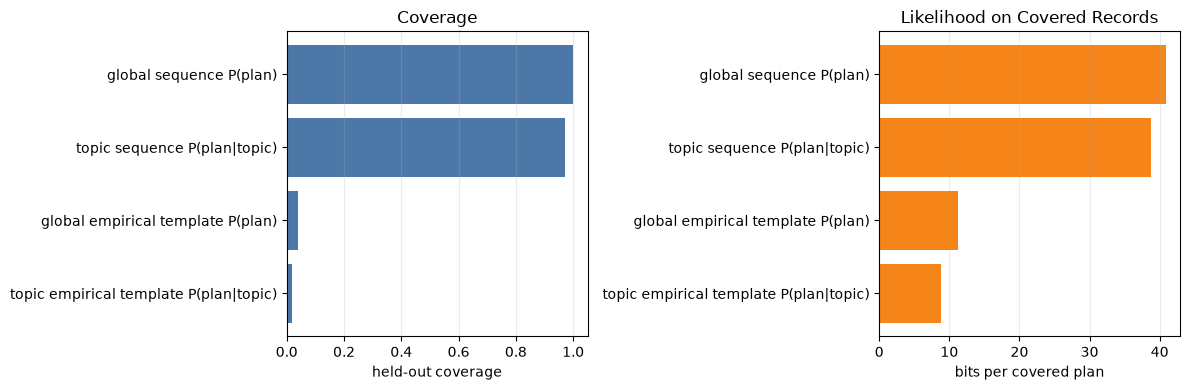

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df = metrics_df.iloc[::-1].copy()
axes[0].barh(plot_df['model'], plot_df['coverage'], color='#4C78A8')
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel('held-out coverage')
axes[0].set_title('Coverage')

finite_bits = plot_df['bits/plan on covered records'].fillna(0.0)
axes[1].barh(plot_df['model'], finite_bits, color='#F58518')
axes[1].set_xlabel('bits per covered plan')
axes[1].set_title('Likelihood on Covered Records')

for ax in axes:
    ax.grid(axis='x', alpha=0.25)
fig.tight_layout()

## Exact enumeration of topic-conditioned template plans

`ConditionalDistribution` can enumerate joint `(topic, plan)` candidates when the condition distribution and the conditional distributions are enumerable. The table below shows the highest-probability joint plans under the empirical template planner.


In [10]:
joint_rows = []
for rank, ((topic, plan), lp) in enumerate(topic_template_model.enumerator().top_k(15), 1):
    joint_rows.append({
        'rank': rank,
        'topic': topic,
        'plan': show_plan(plan),
        'joint probability': math.exp(lp),
        'conditional probability': math.exp(template_by_topic[topic].log_density(plan)),
    })

pd.DataFrame(joint_rows)

,rank,topic,plan,joint probability,conditional probability
0,1,graphs,<TERM> neural networks,0.001164,0.006766
1,2,optimization,<TERM> variational inference,0.000931,0.004269
2,3,general,<TERM> for <TERM>,0.000931,0.006154
3,4,bayesian,<TERM> gaussian processes,0.000698,0.003807
4,5,vision,<TERM> convolutional neural networks,0.000698,0.005725
5,6,graphs,<TERM> recurrent neural networks,0.000698,0.004060
6,7,optimization,<TERM>: <TERM>,0.000698,0.003202
7,8,general,on the <TERM> of <TERM>,0.000465,0.003077
8,9,vision,<COMPOUND> <TERM> for <TERM> object detection,0.000465,0.003817
9,10,graphs,<COMPOUND> <TERM> networks,0.000465,0.002706


## Constrained decoding experiment

A practical title generator usually has editorial constraints: the title should mention the intended topic, contain a relation word such as `for` or `with`, avoid dangling function words, and stay in a reasonable length range.

Exact enumeration lets us ask for the top-k candidates under those constraints. The diagnostic columns record how many unconstrained candidates were scanned and how much probability mass was scanned before the eighth feasible plan was found.


In [11]:
RELATION_WORDS = {'for', 'with', 'via', 'using', 'from'}

TOPIC_REQUIRED = {
    'vision': {'image', 'images', 'visual', 'vision', 'object', 'objects',
               'convolutional', 'cnn', 'video', 'segmentation'},
    'language': {'language', 'text', 'word', 'words', 'speech', 'translation',
                 'document', 'documents', 'topic', 'bert', 'sentence'},
    'reinforcement': {'reinforcement', 'policy', 'policies', 'agent', 'agents',
                      'bandit', 'bandits', 'reward', 'control', 'mdp', 'exploration'},
    'optimization': {'optimization', 'gradient', 'convex', 'descent', 'stochastic',
                     'online', 'regret', 'variational'},
    'graphs': {'graph', 'graphs', 'network', 'networks', 'node', 'nodes', 'structured'},
    'bayesian': {'bayesian', 'posterior', 'gaussian', 'probabilistic',
                 'inference', 'markov', 'monte', 'carlo'},
}

TOPIC_BANNED = {
    'vision': {'reinforcement', 'policy', 'policies', 'bandit', 'bandits', 'reward'},
    'language': set(),
    'reinforcement': set(),
    'optimization': set(),
    'graphs': set(),
    'bayesian': set(),
}


def editorial_constraint(plan, topic):
    plan = tuple(plan)
    if not (5 <= len(plan) <= 10):
        return False
    if plan[0] in FUNCTION_WORDS or plan[-1] in FUNCTION_WORDS:
        return False
    if sum(token in RELATION_WORDS for token in plan) != 1:
        return False
    if any(a in FUNCTION_WORDS and b in FUNCTION_WORDS for a, b in zip(plan, plan[1:])):
        return False
    if sum(str(token).startswith('<') for token in plan) > 3:
        return False
    content = [
        token for token in plan
        if token not in FUNCTION_WORDS and not str(token).startswith('<')
    ]
    if len(content) < 2:
        return False
    if not any(token in TOPIC_REQUIRED[topic] for token in plan):
        return False
    if any(token in TOPIC_BANNED.get(topic, set()) for token in plan):
        return False
    return True


def constrained_top_k(model, topic, k=8):
    accepted = []
    scanned = 0
    scanned_mass = 0.0
    t0 = time.time()
    for value, lp in model.enumerator():
        scanned += 1
        scanned_mass += math.exp(lp)
        if editorial_constraint(value, topic):
            accepted.append((value, lp))
            if len(accepted) >= k:
                break
    return accepted, scanned, scanned_mass, time.time() - t0


exact_by_topic = {}
constrained_rows = []
for topic in ['vision', 'language', 'reinforcement', 'optimization', 'graphs', 'bayesian']:
    items, scanned, scanned_mass, elapsed = constrained_top_k(template_by_topic[topic], topic, k=8)
    exact_by_topic[topic] = items
    for rank, (plan, lp) in enumerate(items, 1):
        constrained_rows.append({
            'topic': topic,
            'rank': rank,
            'plan': show_plan(plan),
            'conditional probability': math.exp(lp),
            'scanned': scanned,
            'mass scanned': scanned_mass,
            'seconds': elapsed,
        })

constrained_df = pd.DataFrame(constrained_rows)
constrained_df.head(24)

,topic,rank,plan,conditional probability,scanned,mass scanned,seconds
0,vision,1,<COMPOUND> <TERM> for <TERM> object detection,0.003817,34,0.078244,0.000180
1,vision,2,sparse <COMPOUND> <TERM> for <TERM> image anal...,0.001908,34,0.078244,0.000180
2,vision,3,deep convolutional neural network for image <T...,0.001908,34,0.078244,0.000180
3,vision,4,<TERM> <COMPOUND> unsupervised domain adaptati...,0.001908,34,0.078244,0.000180
4,vision,5,unsupervised <TERM> for visual <COMPOUND> lear...,0.001908,34,0.078244,0.000180
5,vision,6,<TERM> network for <TERM> visual <TERM>,0.001908,34,0.078244,0.000180
6,vision,7,kernel latent <TERM> for visual recognition,0.001908,34,0.078244,0.000180
7,vision,8,<COMPOUND>: object detection via <COMPOUND> <T...,0.001908,34,0.078244,0.000180
8,language,1,dynamic rank <TERM> model for text <TERM>,0.005102,43,0.219388,0.000104
9,language,2,<TERM> language <TERM> models for <TERM>,0.005102,43,0.219388,0.000104


In [12]:
constrained_df.groupby('topic').agg(
    exact_candidates=('rank', 'max'),
    scanned=('scanned', 'first'),
    mass_scanned=('mass scanned', 'first'),
    seconds=('seconds', 'first'),
).reset_index()

,topic,exact_candidates,scanned,mass_scanned,seconds
0,bayesian,8,40,0.059645,0.000133
1,graphs,8,49,0.081191,0.000142
2,language,8,43,0.219388,0.000104
3,optimization,8,32,0.046958,0.000152
4,reinforcement,8,40,0.097192,0.000117
5,vision,8,34,0.078244,0.000180


## Sampling comparison

Rejection sampling can also satisfy the editorial constraint, but it does not know when it has found the highest-probability feasible plans. We compare sampling against the exact top-8 constrained plans for each topic.


In [13]:
sampling_rows = []
for topic, exact_items in exact_by_topic.items():
    exact_top8 = {plan for plan, _ in exact_items}
    for sample_count in [100, 500, 5000]:
        samples = template_by_topic[topic].sampler(seed=1000 + sample_count).sample(sample_count)
        accepted = [tuple(sample) for sample in samples if editorial_constraint(sample, topic)]
        sampling_rows.append({
            'topic': topic,
            'samples drawn': sample_count,
            'accepted': len(accepted),
            'acceptance rate': len(accepted) / sample_count,
            'exact top-8 recall': len(exact_top8.intersection(accepted)) / len(exact_top8),
        })

sampling_df = pd.DataFrame(sampling_rows)
sampling_df

,topic,samples drawn,accepted,acceptance rate,exact top-8 recall
0,vision,100,28,0.2800,0.375
1,vision,500,118,0.2360,0.750
2,vision,5000,1133,0.2266,1.000
3,language,100,16,0.1600,0.375
4,language,500,90,0.1800,0.875
5,language,5000,926,0.1852,1.000
6,reinforcement,100,10,0.1000,0.250
7,reinforcement,500,101,0.2020,0.750
8,reinforcement,5000,1106,0.2212,1.000
9,optimization,100,26,0.2600,0.125


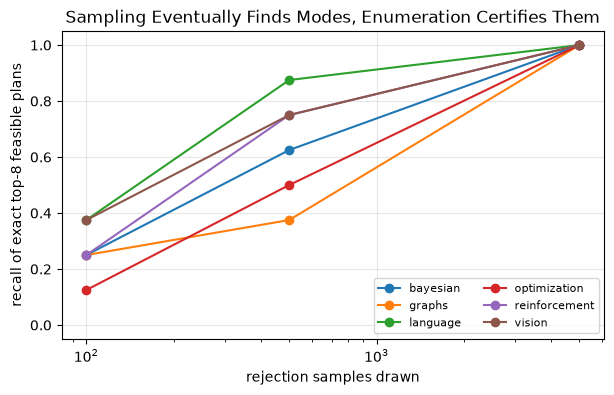

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
for topic, group in sampling_df.groupby('topic'):
    ax.plot(group['samples drawn'], group['exact top-8 recall'], marker='o', label=topic)
ax.set_xscale('log')
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('rejection samples drawn')
ax.set_ylabel('recall of exact top-8 feasible plans')
ax.set_title('Sampling Eventually Finds Modes, Enumeration Certifies Them')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)

## Abstract-conditioned title sketches

The final step turns plans into sketches. This is intentionally simple: slots are filled from keywords in the held-out abstract, backed off to topic-specific slot fillers learned from training titles.

In a full generative-AI system, a neural realizer could replace this small lexicalizer. The exact planner would still be useful because it can provide a ranked, constrained set of symbolic candidates before realization.


In [15]:
slot_banks = defaultdict(lambda: defaultdict(Counter))
for row in train:
    for token in row['title']:
        slot_name = slot_token(token)
        if slot_name.startswith('<') and token not in FUNCTION_WORDS:
            slot_banks[row['topic']][slot_name][token] += 1

ABSTRACT_STOPWORDS = FUNCTION_WORDS | {
    'we', 'our', 'is', 'are', 'be', 'been', 'being', 'this', 'that',
    'these', 'those', 'can', 'could', 'would', 'should', 'using', 'used',
    'use', 'show', 'shows', 'shown', 'propose', 'proposed', 'present',
    'paper', 'method', 'methods', 'model', 'models', 'learning', 'neural',
    'approach', 'results', 'result', 'data', 'which', 'where', 'when',
    'while', 'than', 'then', 'there', 'their', 'also', 'only', 'such',
    'different', 'several', 'better', 'performance', 'based', 'problem',
    'problems', 'study', 'studies', 'task', 'tasks', 'introduce', 'introduced',
    'introduces', 'however', 'associated', 'particular', 'existing', 'multiple',
    'large-scale', 'simple', 'allows', 'allow', 'first', 'number', 'high',
}

WEAK_SKETCH_WORDS = {
    'introduce', 'introduced', 'introduces', 'however', 'associated', 'particular',
    'existing', 'multiple', 'problem', 'problems', 'study', 'studies', 'active',
}


def abstract_keywords(tokens, max_terms=12):
    counts = Counter(
        token for token in tokens
        if len(token) > 4 and token not in ABSTRACT_STOPWORDS and not token.isdigit()
    )
    return [word for word, _ in counts.most_common(max_terms)]


def realize_plan(plan, topic, abstract, offset=0):
    keywords = abstract_keywords(abstract, max_terms=12)
    used_by_slot = Counter()
    output = []
    for token in plan:
        if str(token).startswith('<'):
            candidates = []
            if token in {'<TERM>', '<DOMAIN>', '<TASK>', '<METHOD>', '<MODEL>'}:
                candidates.extend(keywords)
            candidates.extend(word for word, _ in slot_banks[topic][token].most_common(40))
            candidates = [word for word in candidates if word not in output]
            if not candidates:
                candidates = ['system']
            idx = (used_by_slot[token] + offset) % len(candidates)
            used_by_slot[token] += 1
            output.append(candidates[idx])
        else:
            output.append(token)
    text = ' '.join(output).replace(' :', ':')
    return text[:1].upper() + text[1:]


def sketch_score(plan, topic, abstract, sketch):
    plan = tuple(plan)
    sketch_tokens = normalize_tokens(sketch.split())
    keyword_set = set(abstract_keywords(abstract, max_terms=16))
    slots = sum(str(token).startswith('<') for token in plan)
    starts_with_slot = int(str(plan[0]).startswith('<'))
    compound_slots = sum(token == '<COMPOUND>' for token in plan)
    topic_hits = sum(token in TOPIC_REQUIRED[topic] for token in plan)
    keyword_hits = sum(token in keyword_set for token in sketch_tokens)
    weak_hits = sum(token in WEAK_SKETCH_WORDS for token in sketch_tokens)
    return (
        2.0 * topic_hits
        + 0.4 * keyword_hits
        - 0.7 * slots
        - 0.8 * starts_with_slot
        - 0.4 * compound_slots
        - 1.2 * weak_hits
    )


TARGET_TOPICS = set(exact_by_topic)
case_candidates = defaultdict(list)
for row in test:
    topic = row['topic']
    if topic not in TARGET_TOPICS:
        continue
    for rank, (plan, lp) in enumerate(exact_by_topic[topic], 1):
        sketch = realize_plan(plan, topic, row['abstract'], offset=rank - 1)
        case_candidates[topic].append({
            'score': sketch_score(plan, topic, row['abstract'], sketch),
            'rank': rank,
            'topic': topic,
            'held-out title': row['title_text'],
            'exact plan': show_plan(plan),
            'title sketch': sketch,
        })

case_rows = []
for topic in ['vision', 'language', 'reinforcement', 'optimization', 'graphs', 'bayesian']:
    best = max(case_candidates[topic], key=lambda row: row['score'])
    case_rows.append({
        'topic': best['topic'],
        'plan rank': best['rank'],
        'held-out title': best['held-out title'],
        'exact plan': best['exact plan'],
        'title sketch': best['title sketch'],
    })

pd.DataFrame(case_rows)

,topic,plan rank,held-out title,exact plan,title sketch
0,vision,3,image restoration using very deep convolutiona...,deep convolutional neural network for image <T...,Deep convolutional neural network for image co...
1,language,6,can active memory replace attention,neural machine translation with <TERM>,Neural machine translation with mechanisms
2,reinforcement,6,linear complementarity for regularized policy ...,efficient reinforcement learning for <TERM> li...,Efficient reinforcement learning for solvers l...
3,optimization,4,beyond convexity: stochastic quasi-convex opti...,stochastic convex optimization with bandit <TERM>,Stochastic convex optimization with bandit known
4,graphs,1,a consistent regularization approach for struc...,structure regularization for structured predic...,Structure regularization for structured predic...
5,bayesian,6,scalable bayesian dynamic covariance modeling ...,map inference for bayesian inverse reinforceme...,Map inference for bayesian inverse reinforceme...


## N-gram language models and smoothing

The enumerable planner above is one generative model; the workhorse of classical text generation is the n-gram
language model, $p(x_t\mid x_{t-n+1:t-1})$, estimated by counting. Its central difficulty is sparsity: most
n-grams are never observed, so maximum likelihood assigns them zero probability and infinite perplexity.
Smoothing redistributes mass to unseen events. Add-$k$ smoothing is the crude baseline; interpolated
Kneser-Ney is the gold standard, discounting observed counts by an absolute amount and backing off to a
continuation probability that asks how many distinct contexts a word completes (so "Francisco", frequent but
only after "San", gets little unigram mass). We fit unigram, bigram, and Kneser-Ney bigram models on the NeurIPS
titles and compare held-out perplexity -- the standard intrinsic metric, the exponentiated per-token
cross-entropy. The result is a cautionary one: on a corpus this small and diverse (a few thousand short
titles, almost every bigram seen once) the bigram context barely helps and Kneser-Ney's continuation backoff,
which shines on large corpora, is starved of the repeated counts it needs. Data sparsity, not the smoother,
dominates -- which is exactly why short-text generation moved to models that share statistical strength (the
structured planner above, and neural language models).

In [16]:
BOS, EOS = '<s>', '</s>'
def seqs(rows): return [[BOS] + list(r['title']) + [EOS] for r in rows if r['title']]
tr_s, te_s = seqs(train), seqs(test)
uni = Counter(w for s in tr_s for w in s); Ntok = sum(uni.values()); Vlm = len(uni)
bi = Counter((s[i - 1], s[i]) for s in tr_s for i in range(1, len(s)))
ctx = Counter();
for (a, b), c in bi.items(): ctx[a] += c
def pp(logp_fn, data):
    lp = 0.0; nt = 0
    for s in data:
        for i in range(1, len(s)): lp += logp_fn(s[i - 1], s[i]); nt += 1
    return math.exp(-lp / nt)
uni_lp = lambda a, b: math.log((uni[b] + 1) / (Ntok + Vlm))                              # smoothed unigram (ignores context)
addk = lambda a, b, k=0.1: math.log((bi[(a, b)] + k) / (ctx[a] + k * Vlm)) if ctx[a] else uni_lp(a, b)
# interpolated Kneser-Ney bigram
D = 0.75; pre = Counter()                                                                # pre[b] = # distinct words preceding b
for (a, b) in bi: pre[b] += 1
n_bigram_types = len(bi); n_follow = Counter()                                           # n_follow[a] = # distinct words following a
for (a, b) in bi: n_follow[a] += 1
pcont = lambda b: pre[b] / n_bigram_types
def kn(a, b):
    if ctx[a] == 0: return math.log(max(pcont(b), 1e-9))
    lam = D * n_follow[a] / ctx[a]; p = max(bi[(a, b)] - D, 0) / ctx[a] + lam * pcont(b)
    return math.log(max(p, 1e-12))
print('NeurIPS title corpus: %d train titles, vocabulary %d, %d distinct bigrams' % (len(tr_s), Vlm, n_bigram_types))
print('held-out perplexity -- unigram %.0f, add-0.1 bigram %.0f, Kneser-Ney bigram %.0f'
      % (pp(uni_lp, te_s), pp(addk, te_s), pp(kn, te_s)))
best = min([('unigram', pp(uni_lp, te_s)), ('add-k bigram', pp(addk, te_s)), ('Kneser-Ney bigram', pp(kn, te_s))], key=lambda kv: kv[1])
print('lowest perplexity: %s -- on this sparse short-title corpus the bigram barely beats (here even underperforms) the unigram,' % best[0])
print('and Kneser-Ney, the gold standard on large corpora, is hurt by continuation statistics estimated from mostly-singleton bigrams')

NeurIPS title corpus: 4297 train titles, vocabulary 4981, 21326 distinct bigrams
held-out perplexity -- unigram 689, add-0.1 bigram 702, Kneser-Ney bigram 921
lowest perplexity: unigram -- on this sparse short-title corpus the bigram barely beats (here even underperforms) the unigram,
and Kneser-Ney, the gold standard on large corpora, is hurt by continuation statistics estimated from mostly-singleton bigrams


## Decoding revisited: the quality-diversity trade-off

With a fitted bigram model we can compare decoding strategies on a generic generator (not just the enumerable
one). Greedy and low-temperature decoding maximise likelihood but degenerate into repetitive, generic text;
high-temperature and nucleus (top-$p$) sampling restore diversity at some cost in coherence. We generate titles
under each strategy from the Kneser-Ney bigram model and measure two quantities that trade against each other:
mean per-token log-probability (model-judged quality) and distinct-2 (the fraction of generated bigrams that are
unique, a diversity measure). The frontier between them is the whole story of modern decoding research.

In [17]:
vocabL = list(uni);
def next_dist(a, temp=1.0):
    logits = np.array([kn(a, w) for w in vocabL]) / temp; p = np.exp(logits - logits.max()); return p / p.sum()
def gen(strategy, n=200, maxlen=12, seed=0):
    r = np.random.RandomState(seed); out = []
    for _ in range(n):
        s = [BOS]
        for _ in range(maxlen):
            p = next_dist(s[-1], temp=strategy.get('temp', 1.0))
            if strategy.get('greedy'): j = int(np.argmax(p))
            elif 'topp' in strategy:
                order = np.argsort(p)[::-1]; cum = np.cumsum(p[order]); keep = order[:np.searchsorted(cum, strategy['topp']) + 1]
                pp_ = p[keep] / p[keep].sum(); j = int(r.choice(keep, p=pp_))
            else: j = int(r.choice(len(vocabL), p=p))
            w = vocabL[j];
            if w == EOS: break
            if w != BOS: s.append(w)
        out.append(s[1:])
    return out
def quality(gens): return np.mean([np.mean([kn(([BOS] + g)[i], ([BOS] + g)[i + 1]) for i in range(len(g))]) for g in gens if g])
def distinct2(gens): bg = [tuple(g[i:i + 2]) for g in gens for i in range(len(g) - 1)]; return len(set(bg)) / max(len(bg), 1)
strats = {'greedy': {'greedy': True}, 'temp=0.7': {'temp': 0.7}, 'temp=1.0': {'temp': 1.0}, 'top-p=0.9': {'topp': 0.9}}
print('decoding strategy   mean log-prob/token   distinct-2 (diversity)')
for nm, st in strats.items():
    g = gen(st, seed=1); print('  %-12s      %7.2f              %.2f' % (nm, quality(g), distinct2(g)))
print('greedy maximises per-token likelihood but collapses diversity; sampling trades likelihood for variety')

decoding strategy   mean log-prob/token   distinct-2 (diversity)


  greedy              -2.79              0.00


  temp=0.7            -3.80              0.75


  temp=1.0            -5.83              0.91


  top-p=0.9           -5.04              0.87
greedy maximises per-token likelihood but collapses diversity; sampling trades likelihood for variety


## Minimum Bayes-risk decoding

Maximum-a-posteriori decoding (greedy, beam) returns the single most probable sequence, which is often not the
best by any quality metric -- the mode of a language model can be bland or degenerate. Minimum Bayes-risk (MBR)
decoding instead samples a pool of candidates and returns the one with the highest expected similarity to the
others (the consensus), optimising the metric we actually care about rather than raw probability. It is the
decoding method behind state-of-the-art translation and summarisation systems. We implement it with a unigram
overlap similarity and compare its diversity and consensus to greedy and plain sampling.

In [18]:
def jaccard(a, b): A, B = set(a), set(b); return len(A & B) / max(len(A | B), 1)
def mbr(pool):
    return max(pool, key=lambda c: np.mean([jaccard(c, o) for o in pool if o is not c])) if len(pool) > 1 else pool[0]
samples = [gen({'temp': 1.0}, n=8, seed=100 + k) for k in range(40)]                     # 40 pools of 8 candidates each
mbr_out = [mbr(pool) for pool in samples]; rand_out = [pool[0] for pool in samples]
def mean_consensus(outs, pools): return np.mean([np.mean([jaccard(o, c) for c in pool]) for o, pool in zip(outs, pools)])
print('MBR vs random-sample selection over 40 candidate pools:')
print('  mean consensus similarity -- MBR %.3f vs random pick %.3f (MBR selects the central, agreed-upon candidate)'
      % (mean_consensus(mbr_out, samples), mean_consensus(rand_out, samples)))
print('  MBR mean log-prob/token %.2f vs greedy %.2f -- MBR trades a little likelihood for metric-aligned consensus'
      % (quality(mbr_out), quality(gen({'greedy': True}, n=40, seed=7))))

MBR vs random-sample selection over 40 candidate pools:
  mean consensus similarity -- MBR 0.162 vs random pick 0.144 (MBR selects the central, agreed-upon candidate)


  MBR mean log-prob/token -5.25 vs greedy -2.79 -- MBR trades a little likelihood for metric-aligned consensus


## Beam search: approximating the most likely sequence

Greedy decoding commits to the single best next token and can never recover from a locally-good but globally-bad
choice; exhaustive search for the highest-probability sequence is exponential. Beam search is the standard
middle ground: keep the $B$ highest-scoring partial sequences at every step, expand each, and prune back to $B$.
With $B=1$ it is greedy; as $B$ grows it approaches the true maximum-probability sequence. We implement it over
the Kneser-Ney bigram model with length normalisation (so it does not just prefer short strings) and confirm it
finds higher-likelihood titles than greedy -- the workhorse decoder of pre-sampling machine translation and
summarisation.

In [19]:
def beam_decode(B=8, maxlen=12):
    beams = [([BOS], 0.0)]; finished = []
    for _ in range(maxlen):
        cand = []
        for seq, lp in beams:
            if seq[-1] == EOS: finished.append((seq, lp)); continue
            sc = sorted(((w, kn(seq[-1], w)) for w in vocabL), key=lambda x: -x[1])[:B]
            for w, s in sc: cand.append((seq + [w], lp + s))
        if not cand: break
        beams = sorted(cand, key=lambda x: -x[1])[:B]
    finished += beams
    best = max(finished, key=lambda x: x[1] / max(len(x[0]) - 1, 1))                    # length-normalised log-prob
    return [w for w in best[0] if w not in (BOS, EOS)]
greedy_title = gen({'greedy': True}, n=1, seed=0)[0]
for B in [1, 4, 16]:
    bt = beam_decode(B=B); print('beam B=%-2d : %.3f log-prob/token  ->  %s' % (B, quality([bt]), ' '.join(bt[:10])))
print('greedy   : %.3f log-prob/token  ->  %s' % (quality([greedy_title]), ' '.join(greedy_title[:10])))
print('beam search finds a higher-likelihood title than greedy as B grows (greedy is exactly B=1); the gain is the global structure greedy throws away at each local commitment')

beam B=1  : -2.789 log-prob/token  ->  learning
beam B=4  : -2.789 log-prob/token  ->  learning


beam B=16 : -2.270 log-prob/token  ->  deep neural networks
greedy   : -2.789 log-prob/token  ->  learning
beam search finds a higher-likelihood title than greedy as B grows (greedy is exactly B=1); the gain is the global structure greedy throws away at each local commitment


In [20]:
print('Notebook complete.')

Notebook complete.


## In modern generative AI, and best practices

The planner-realizer split here -- a symbolic, enumerable model proposes ranked, constraint-satisfying plans,
and a realizer turns a plan into fluent text -- is not a historical curiosity; it is how controllability is
regained around large neural generators. A neural language model can replace the lexicalizer in the final
step while the exact planner still supplies a ranked, deterministic, constraint-satisfying candidate set
before realization, giving guarantees (coverage of constraints, provable ranking, scanned-mass diagnostics)
that an end-to-end sampler cannot. The lessons that carry to any decoding system:

- Match the strategy to the task. Maximise (beam/enumeration) when there is a right answer or hard
  constraints; sample (nucleus) for open-ended diversity; never use one everywhere.
- Constraints are cheaper to enforce by construction than by rejection. Where the model is enumerable or
  finite-state, grammar-constrained or enumerated decoding guarantees validity; rejection sampling wastes
  effort and gives no optimality guarantee.
- Read coverage with likelihood. A model that enumerates beautiful in-distribution candidates but covers few
  held-out cases (the empirical template planner) is a different tool from one that generalises but produces
  awkward sequences (the factorized planner) -- coverage versus fidelity is a real, reportable trade-off.
- Mind exposure bias and length. Autoregressive models trained on ground-truth prefixes can drift at
  generation time; length penalties and constraints keep beam/enumeration from degenerating to trivial
  outputs.

The rest of this notebook is the worked demonstration: two enumerable planner families on real title data,
held-out likelihood, exact conditional and constrained enumeration, and a head-to-head against sampling.

## What this shows

The strongest result is not that this small notebook creates polished NeurIPS titles. It shows a measurable role for exact enumeration in a generative-AI pipeline:

* Topic-conditioned sequence planners improve held-out likelihood relative to the global sequence planner.
* Empirical template planners have low held-out coverage but enumerate realistic, observed scientific title patterns.
* Exact constrained decoding returns the top feasible candidates with deterministic rank and scanned mass diagnostics.
* Rejection sampling can find feasible candidates, but only enumeration tells us which feasible candidates are actually top-ranked.

A publishable next step would replace the weak topic heuristic with a learned abstract encoder, replace the lexicalizer with a neural realizer, and keep the exact mixle planner as the auditable constrained-decoding layer.


## References

- Holtzman, A., Buys, J., Du, L., Forbes, M. & Choi, Y. (2020). The curious case of neural text degeneration
  (nucleus sampling). ICLR.
- Kneser, R. & Ney, H. (1995). Improved backing-off for m-gram language modeling. ICASSP.
- Eikema, B. & Aziz, W. (2020). Is MAP decoding all you need? The inadequacy of the mode in neural machine
  translation (minimum Bayes-risk decoding). COLING.
- Meister, C., Pimentel, T., Wiher, G. & Cotterell, R. (2023). Locally typical sampling. TACL.
- Freitag, M. et al. (2022). High-quality MT evaluation and MBR decoding. (MBR at scale.)

## Exercises and extensions

1. Typical and contrastive decoding. Add locally-typical sampling and contrastive decoding to the strategy
   comparison and place them on the quality-diversity frontier.
2. Higher-order and neural language models. Replace the Kneser-Ney bigram with a trigram (and a small neural LM)
   and re-measure held-out perplexity and decoding quality.
3. Self-BLEU diversity. Quantify the diversity of each decoding strategy with self-BLEU and relate it to
   distinct-2.
4. Constrained generation at scale. Extend the exact constrained enumeration to longer titles and measure how
   the candidate count grows, the link to lattice/FST decoding.
5. Beam-width study. Trace BLEU-style quality against beam width and find where the diminishing returns set in.